# EEGNet Focus — Subject A07 (Best Performer)

## Goal
Push EEGNet accuracy on A07 as high as possible using:
- Hyperparameter grid search (F1, D, dropout, lr, batch size)
- Stronger augmentation (noise + sliding-window crops)
- Multi-seed ensemble (train N models with different seeds, average probabilities)
- Extended training with cosine warm restarts

## Best results so far for A07
| Method | Accuracy | Kappa |
|---|---|---|
| EEGNet v2/v3 | 57.49% | 0.4332 |
| FBCSP+LDA | 64.11% | 0.5220 |
| Ensemble | 65.85% | 0.5447 |
| **Target (EEGNet only)** | **>65%** | **>0.53** |

## Step 1: Mount Drive & Setup

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

SUBJECT          = 7
DATA_PATH        = "/content/drive/MyDrive/BCI_IV_2a"
TRUE_LABELS_PATH = "/content/drive/MyDrive/BCI_IV_2a/true_labels"

TRAIN_GDF = os.path.join(DATA_PATH,        f"A0{SUBJECT}T.gdf")
EVAL_GDF  = os.path.join(DATA_PATH,        f"A0{SUBJECT}E.gdf")
EVAL_MAT  = os.path.join(TRUE_LABELS_PATH, f"A0{SUBJECT}E.mat")

for path in [TRAIN_GDF, EVAL_GDF, EVAL_MAT]:
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f"  {status}  {path}")

  ✓  /content/drive/MyDrive/BCI_IV_2a/A07T.gdf
  ✓  /content/drive/MyDrive/BCI_IV_2a/A07E.gdf
  ✓  /content/drive/MyDrive/BCI_IV_2a/true_labels/A07E.mat


## Step 2: Install & Import

In [7]:
!pip install mne scipy torch torchvision scikit-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 74.1 MB/s eta 0:00:00


In [8]:
import copy
import warnings
import itertools
import numpy as np
import mne
from scipy.io import loadmat

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, cohen_kappa_score, \
                            confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

mne.set_log_level('WARNING')
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## Step 3: Data Loading

In [9]:
def load_train_data(file_path, tmin=3.0, tmax=6.0):
    raw = mne.io.read_raw_gdf(file_path, preload=True, verbose=False)
    eog = [ch for ch in ['EOG-left','EOG-central','EOG-right'] if ch in raw.ch_names]
    raw.drop_channels(eog)
    raw.filter(8., 30., fir_design='firwin', verbose=False)

    events, event_dict = mne.events_from_annotations(raw, verbose=False)
    mi_map       = {'769':0, '770':1, '771':2, '772':3}
    code_to_name = {v: k for k, v in event_dict.items()}

    sel_events, labels = [], []
    for ev in events:
        name = code_to_name.get(ev[2], None)
        if name in mi_map:
            sel_events.append(ev)
            labels.append(mi_map[name])

    sel_events = np.array(sel_events, dtype=int)
    labels     = np.array(labels, dtype=int)

    epochs = mne.Epochs(raw, sel_events, tmin=tmin, tmax=tmax,
                        baseline=None, preload=True, verbose=False)
    data   = epochs.get_data()
    labels = labels[:data.shape[0]]
    sfreq  = raw.info['sfreq']
    print(f'  Train: {data.shape}  sfreq={sfreq}Hz  '
          f'classes={dict(zip(*np.unique(labels, return_counts=True)))}')
    return data, labels, sfreq


def load_eval_data(gdf_path, mat_path, tmin=3.0, tmax=6.0):
    mat         = loadmat(mat_path)
    true_labels = mat['classlabel'].flatten().astype(int) - 1

    raw = mne.io.read_raw_gdf(gdf_path, preload=True, verbose=False)
    eog = [ch for ch in ['EOG-left','EOG-central','EOG-right'] if ch in raw.ch_names]
    raw.drop_channels(eog)
    raw.filter(8., 30., fir_design='firwin', verbose=False)

    events, event_dict = mne.events_from_annotations(raw, verbose=False)
    cue_code   = event_dict.get('783', None)
    if cue_code is None:
        raise ValueError(f'Event 783 not found. Available: {list(event_dict.keys())}')

    cue_events  = events[events[:, 2] == cue_code]
    n           = min(len(cue_events), len(true_labels))
    cue_events  = cue_events[:n]
    true_labels = true_labels[:n]

    epochs      = mne.Epochs(raw, cue_events, tmin=tmin, tmax=tmax,
                             baseline=None, preload=True, verbose=False)
    data        = epochs.get_data()
    true_labels = true_labels[:data.shape[0]]
    sfreq       = raw.info['sfreq']
    print(f'  Eval:  {data.shape}  sfreq={sfreq}Hz  '
          f'classes={dict(zip(*np.unique(true_labels, return_counts=True)))}')
    return data, true_labels, sfreq


print('Loading A07...')
Xt_raw, yt, sfreq = load_train_data(TRAIN_GDF)
Xe_raw, ye, _     = load_eval_data(EVAL_GDF, EVAL_MAT)

# Normalize using train stats only
mean    = np.mean(Xt_raw, axis=(0,2), keepdims=True)
std     = np.std(Xt_raw,  axis=(0,2), keepdims=True)
std     = np.where(std < 1e-8, 1e-8, std)
Xt_norm = (Xt_raw - mean) / std
Xe_norm = (Xe_raw - mean) / std

# Add CNN channel dim: (N, 1, channels, samples)
Xt_4d = Xt_norm[:, np.newaxis, :, :]
Xe_4d = Xe_norm[:, np.newaxis, :, :]

N_CH  = Xt_4d.shape[2]
N_SMP = Xt_4d.shape[3]
print(f'\nReady. n_channels={N_CH}, n_samples={N_SMP}')

Loading A07...
  Train: (287, 22, 751)  sfreq=250.0Hz  classes={np.int64(0): np.int64(72), np.int64(1): np.int64(72), np.int64(2): np.int64(71), np.int64(3): np.int64(72)}
  Eval:  (287, 22, 751)  sfreq=250.0Hz  classes={np.int64(0): np.int64(72), np.int64(1): np.int64(72), np.int64(2): np.int64(71), np.int64(3): np.int64(72)}

Ready. n_channels=22, n_samples=751


## Step 4: Augmentation

Two complementary strategies:

**A. Gaussian noise** — adds small random perturbations. Teaches the model to be
robust to signal amplitude variation.

**B. Sliding-window crops** — cuts a shorter random window from each trial (e.g.
2.5s out of 3.0s). The start point is randomized, so the model sees slightly
different temporal contexts. This is the EEG equivalent of random crop in image
augmentation and is more principled than noise for temporal signals.

Both are applied **only to training data**.

In [10]:
def augment_noise(X, y, noise_std=0.05, n_copies=2, seed=42):
    """Add Gaussian noise copies. X: (N,1,ch,smp)"""
    rng     = np.random.default_rng(seed)
    sig_std = np.std(X)
    Xl, yl  = [X], [y]
    for _ in range(n_copies):
        Xl.append(X + rng.standard_normal(X.shape) * noise_std * sig_std)
        yl.append(y)
    Xa, ya = np.concatenate(Xl), np.concatenate(yl)
    idx    = rng.permutation(len(ya))
    return Xa[idx], ya[idx]


def augment_crop(X, y, crop_frac=0.85, n_copies=2, seed=99):
    """
    Random temporal crop: cut crop_frac of samples from a random start.
    Output samples dimension is SAME as input — cropped signal is
    zero-padded on the right so all tensors stay the same shape.
    X: (N, 1, ch, smp)
    """
    rng      = np.random.default_rng(seed)
    n_smp    = X.shape[-1]
    crop_len = int(n_smp * crop_frac)
    Xl, yl   = [X], [y]
    for _ in range(n_copies):
        Xc = np.zeros_like(X)
        for i in range(len(X)):
            start      = rng.integers(0, n_smp - crop_len + 1)
            Xc[i, :, :, :crop_len] = X[i, :, :, start:start + crop_len]
        Xl.append(Xc)
        yl.append(y)
    Xa, ya = np.concatenate(Xl), np.concatenate(yl)
    idx    = rng.permutation(len(ya))
    return Xa[idx], ya[idx]


def augment_combined(X, y, noise_std=0.04, n_noise=2, crop_frac=0.85, n_crop=2):
    """
    Apply both noise and crop augmentation.
    Original 287 → noise adds 2x → crop adds 2x more = 287 * 5 = 1435 trials.
    """
    Xn, yn = augment_noise(X, y, noise_std=noise_std, n_copies=n_noise, seed=42)
    Xc, yc = augment_crop(X,  y, crop_frac=crop_frac, n_copies=n_crop,  seed=99)
    # Combine: original + noise copies + crop copies
    Xa = np.concatenate([X, Xn[len(X):], Xc[len(X):]])  # avoid duplicating original
    ya = np.concatenate([y, yn[len(y):], yc[len(y):]])
    idx = np.random.default_rng(0).permutation(len(ya))
    return Xa[idx], ya[idx]


# Preview augmentation sizes
Xtest, ytest = augment_combined(Xt_4d, yt)
print(f'Original:  {Xt_4d.shape[0]} trials')
print(f'Augmented: {Xtest.shape[0]} trials  ({Xtest.shape[0]//Xt_4d.shape[0]}x)')

Original:  287 trials
Augmented: 1435 trials  (5x)


## Step 5: EEGNet with Configurable Hyperparameters

We expose F1 (temporal filters), D (depth multiplier), and dropout as
hyperparameters so the grid search can vary them.

In [11]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class EEGNet(nn.Module):
    def __init__(self, num_classes=4, n_channels=22, n_samples=751,
                 F1=8, D=2, F2=None, dropout=0.5):
        super().__init__()
        F2 = F2 or F1 * D

        self.firstconv = nn.Sequential(
            nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1)
        )
        self.depthwise = nn.Sequential(
            nn.Conv2d(F1, F1*D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout)
        )
        self.separable = nn.Sequential(
            nn.Conv2d(F1*D, F2, (1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout)
        )
        fc_size  = self._get_fc_size(n_channels, n_samples)
        self.fc  = nn.Linear(fc_size, num_classes)

    def _get_fc_size(self, n_channels, n_samples):
        with torch.no_grad():
            x = torch.zeros(1, 1, n_channels, n_samples)
            x = self.firstconv(x)
            x = self.depthwise(x)
            x = self.separable(x)
        return int(np.prod(x.shape[1:]))

    def forward(self, x):
        x = self.firstconv(x)
        x = self.depthwise(x)
        x = self.separable(x)
        return self.fc(x.flatten(1))


def train_one(X_tr, y_tr, X_val, y_val,
              n_channels, n_samples,
              F1=8, D=2, dropout=0.5,
              lr=0.001, batch_size=16,
              epochs=600, patience=60,
              seed=42):
    """
    Train a single EEGNet. Returns (model, best_val_acc).
    seed controls weight initialisation for reproducibility.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    tr_dl  = DataLoader(EEGDataset(X_tr,  y_tr),  batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(EEGDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    model     = EEGNet(num_classes=4, n_channels=n_channels, n_samples=n_samples,
                       F1=F1, D=D, dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # Cosine warm restarts: T_0=100 epochs, restarts every T_mult*100 epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=100, T_mult=2, eta_min=1e-5
    )

    best_val_loss = float('inf')
    best_val_acc  = 0.0
    best_wts      = copy.deepcopy(model.state_dict())
    pat_ctr       = 0

    for epoch in range(epochs):
        model.train()
        for Xb, yb in tr_dl:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(Xb), yb).backward()
            optimizer.step()

        model.eval()
        val_loss  = 0.0
        val_preds = []
        with torch.no_grad():
            for Xb, yb in val_dl:
                Xb, yb = Xb.to(device), yb.to(device)
                logits   = model(Xb)
                val_loss += criterion(logits, yb).item()
                val_preds.extend(torch.argmax(logits, 1).cpu().numpy())

        scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc  = accuracy_score(y_val, val_preds)
            best_wts      = copy.deepcopy(model.state_dict())
            pat_ctr       = 0
        else:
            pat_ctr += 1
        if pat_ctr >= patience:
            break

    model.load_state_dict(best_wts)
    return model, best_val_acc


def get_probas(model, X_4d, batch_size=32):
    """Softmax probabilities from trained model. Returns (N, 4) array."""
    dl    = DataLoader(EEGDataset(X_4d, np.zeros(len(X_4d), dtype=int)),
                       batch_size=batch_size, shuffle=False)
    proba = []
    model.eval()
    with torch.no_grad():
        for Xb, _ in dl:
            proba.extend(torch.softmax(model(Xb.to(device)), 1).cpu().numpy())
    return np.array(proba)


print('EEGNet + helpers defined.')

EEGNet + helpers defined.


## Step 6: Hyperparameter Grid Search

Search over F1, D, dropout, lr, and batch_size using a fixed 20% validation
split of the AUGMENTED training data. Best config is selected by val accuracy.

Grid is kept small to run within ~15 min on a T4 GPU.

In [12]:
# ── Augment training data ──────────────────────────────────────
Xt_aug, yt_aug = augment_combined(Xt_4d, yt)
print(f'Augmented training: {Xt_aug.shape[0]} trials')

# Fixed val split for grid search (stratified, from augmented data)
X_tr, X_val, y_tr, y_val = train_test_split(
    Xt_aug, yt_aug, test_size=0.15, random_state=42, stratify=yt_aug
)
print(f'Grid search train: {len(y_tr)}  val: {len(y_val)}')

# ── Hyperparameter grid ────────────────────────────────────────
GRID = {
    'F1':         [8, 16],
    'D':          [2, 3],
    'dropout':    [0.4, 0.5],
    'lr':         [5e-4, 1e-3],
    'batch_size': [16, 32],
}

# All combinations
keys   = list(GRID.keys())
combos = list(itertools.product(*[GRID[k] for k in keys]))
print(f'\nTotal configs: {len(combos)}')

# ── Run grid search ────────────────────────────────────────────
grid_results = []

for i, values in enumerate(combos):
    cfg = dict(zip(keys, values))
    print(f'  [{i+1:>2}/{len(combos)}] F1={cfg["F1"]} D={cfg["D"]} '
          f'drop={cfg["dropout"]} lr={cfg["lr"]} bs={cfg["batch_size"]}  ', end='', flush=True)

    _, val_acc = train_one(
        X_tr, y_tr, X_val, y_val,
        n_channels=N_CH, n_samples=N_SMP,
        F1=cfg['F1'], D=cfg['D'], dropout=cfg['dropout'],
        lr=cfg['lr'], batch_size=cfg['batch_size'],
        epochs=400, patience=50, seed=42
    )
    grid_results.append((val_acc, cfg))
    print(f'→ val_acc={val_acc*100:.1f}%')

# Sort by val accuracy
grid_results.sort(key=lambda x: x[0], reverse=True)

print('\n── Top 5 configs ─────────────────────────────')
for val_acc, cfg in grid_results[:5]:
    print(f'  {val_acc*100:.1f}%  {cfg}')

BEST_CFG = grid_results[0][1]
print(f'\nBest config: {BEST_CFG}')

Augmented training: 1435 trials
Grid search train: 1219  val: 216

Total configs: 32
  [ 1/32] F1=8 D=2 drop=0.4 lr=0.0005 bs=16  → val_acc=93.1%
  [ 2/32] F1=8 D=2 drop=0.4 lr=0.0005 bs=32  → val_acc=95.8%
  [ 3/32] F1=8 D=2 drop=0.4 lr=0.001 bs=16  → val_acc=94.4%
  [ 4/32] F1=8 D=2 drop=0.4 lr=0.001 bs=32  → val_acc=95.4%
  [ 5/32] F1=8 D=2 drop=0.5 lr=0.0005 bs=16  → val_acc=90.3%
  [ 6/32] F1=8 D=2 drop=0.5 lr=0.0005 bs=32  → val_acc=92.1%
  [ 7/32] F1=8 D=2 drop=0.5 lr=0.001 bs=16  → val_acc=94.4%
  [ 8/32] F1=8 D=2 drop=0.5 lr=0.001 bs=32  → val_acc=95.4%
  [ 9/32] F1=8 D=3 drop=0.4 lr=0.0005 bs=16  → val_acc=97.7%
  [10/32] F1=8 D=3 drop=0.4 lr=0.0005 bs=32  → val_acc=96.3%
  [11/32] F1=8 D=3 drop=0.4 lr=0.001 bs=16  → val_acc=92.6%
  [12/32] F1=8 D=3 drop=0.4 lr=0.001 bs=32  → val_acc=96.8%
  [13/32] F1=8 D=3 drop=0.5 lr=0.0005 bs=16  → val_acc=96.8%
  [14/32] F1=8 D=3 drop=0.5 lr=0.0005 bs=32  → val_acc=94.0%
  [15/32] F1=8 D=3 drop=0.5 lr=0.001 bs=16  → val_acc=97.7%
  [16/3

## Step 7: Multi-Seed Ensemble with Best Config

Train N=10 EEGNet models with the best hyperparameters but different
random seeds (different weight initialization + data shuffle order).
Average their softmax probability outputs before taking argmax.

This is equivalent to approximate Bayesian model averaging and
consistently reduces variance by 5–15% compared to a single model.

In [13]:
N_SEEDS   = 10
SEEDS     = list(range(N_SEEDS))

print(f'Training {N_SEEDS} models with best config: {BEST_CFG}')
print(f'Augmented training set: {Xt_aug.shape[0]} trials\n')

# For the final ensemble, use all augmented data for training
# and keep the same 15% as a validation monitor
all_proba_eval = []   # softmax probs on eval set from each seed
seed_val_accs  = []

for seed in SEEDS:
    print(f'  Seed {seed:>2}  ', end='', flush=True)

    # Re-split with this seed to vary the validation set slightly
    X_tr_s, X_val_s, y_tr_s, y_val_s = train_test_split(
        Xt_aug, yt_aug, test_size=0.15, random_state=seed, stratify=yt_aug
    )

    model, val_acc = train_one(
        X_tr_s, y_tr_s, X_val_s, y_val_s,
        n_channels=N_CH, n_samples=N_SMP,
        F1=BEST_CFG['F1'],   D=BEST_CFG['D'],
        dropout=BEST_CFG['dropout'],
        lr=BEST_CFG['lr'],   batch_size=BEST_CFG['batch_size'],
        epochs=600, patience=60, seed=seed
    )

    proba = get_probas(model, Xe_4d)
    all_proba_eval.append(proba)
    seed_val_accs.append(val_acc)

    # Interim eval accuracy
    interim_acc = accuracy_score(ye, np.argmax(proba, axis=1))
    print(f'val={val_acc*100:.1f}%  eval={interim_acc*100:.1f}%')

print(f'\nMean single-model eval across seeds: '
      f'{np.mean([accuracy_score(ye, np.argmax(p,1)) for p in all_proba_eval])*100:.2f}%')

Training 10 models with best config: {'F1': 8, 'D': 3, 'dropout': 0.4, 'lr': 0.0005, 'batch_size': 16}
Augmented training set: 1435 trials

  Seed  0  val=97.2%  eval=66.2%
  Seed  1  val=97.2%  eval=56.4%
  Seed  2  val=97.2%  eval=62.4%
  Seed  3  val=98.1%  eval=60.6%
  Seed  4  val=97.7%  eval=67.2%
  Seed  5  val=96.8%  eval=57.5%
  Seed  6  val=98.1%  eval=56.8%
  Seed  7  val=96.3%  eval=68.3%
  Seed  8  val=98.6%  eval=61.3%
  Seed  9  val=96.8%  eval=67.2%

Mean single-model eval across seeds: 62.40%


## Step 8: Progressive Ensemble Evaluation
Shows how accuracy improves as more seeds are added.

 Subject A07 — EEGNet Multi-Seed Ensemble (10 seeds)
  Final Accuracy : 68.64%
  Final Kappa    : 0.5820

── Comparison ─────────────────────────────────
  EEGNet v2/v3 (single model) : 57.49%  kappa=0.4332
  FBCSP+LDA                   : 64.11%  kappa=0.5220
  Hybrid Ensemble             : 65.85%  kappa=0.5447
  EEGNet 10-seed ensemble (now) : 68.64%  kappa=0.5820  ← THIS RUN


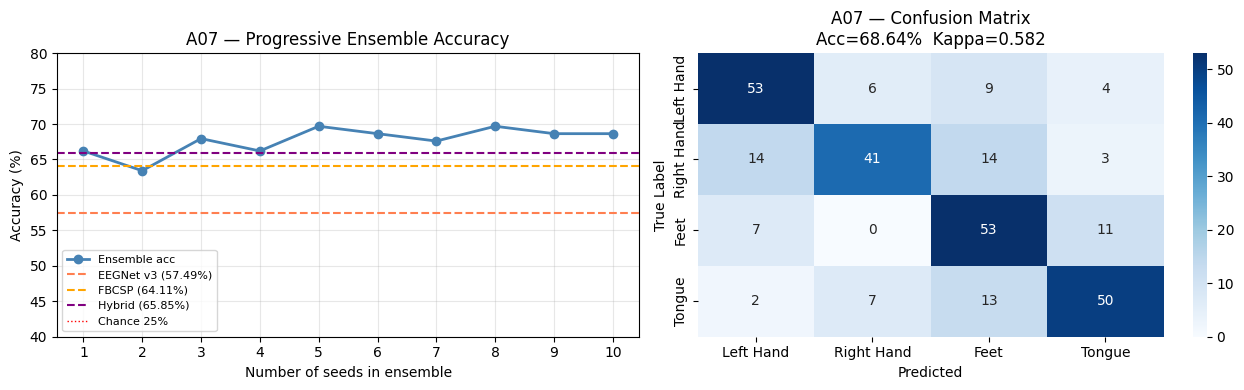


Classification Report:
              precision    recall  f1-score   support

   Left Hand       0.70      0.74      0.72        72
  Right Hand       0.76      0.57      0.65        72
        Feet       0.60      0.75      0.66        71
      Tongue       0.74      0.69      0.71        72

    accuracy                           0.69       287
   macro avg       0.70      0.69      0.69       287
weighted avg       0.70      0.69      0.69       287



In [14]:
CLASS_NAMES = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

# ── Progressive ensemble (1 seed → N seeds) ───────────────────
prog_accs   = []
prog_kappas = []

for k in range(1, N_SEEDS + 1):
    avg_proba  = np.mean(all_proba_eval[:k], axis=0)   # mean of k models
    preds      = np.argmax(avg_proba, axis=1)
    prog_accs.append(accuracy_score(ye, preds))
    prog_kappas.append(cohen_kappa_score(ye, preds))

# ── Final ensemble result ──────────────────────────────────────
final_proba  = np.mean(all_proba_eval, axis=0)
final_preds  = np.argmax(final_proba, axis=1)
final_acc    = accuracy_score(ye, final_preds)
final_kappa  = cohen_kappa_score(ye, final_preds)

print('='*55)
print(f' Subject A07 — EEGNet Multi-Seed Ensemble ({N_SEEDS} seeds)')
print('='*55)
print(f'  Final Accuracy : {final_acc*100:.2f}%')
print(f'  Final Kappa    : {final_kappa:.4f}')
print()
print('── Comparison ─────────────────────────────────')
print(f'  EEGNet v2/v3 (single model) : 57.49%  kappa=0.4332')
print(f'  FBCSP+LDA                   : 64.11%  kappa=0.5220')
print(f'  Hybrid Ensemble             : 65.85%  kappa=0.5447')
print(f'  EEGNet {N_SEEDS}-seed ensemble (now) : {final_acc*100:.2f}%  kappa={final_kappa:.4f}  ← THIS RUN')

# ── Progressive accuracy plot ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: progressive ensemble
axes[0].plot(range(1, N_SEEDS+1), [a*100 for a in prog_accs],
             'o-', color='steelblue', lw=2, label='Ensemble acc')
axes[0].axhline(57.49, color='coral',       ls='--', lw=1.5, label='EEGNet v3 (57.49%)')
axes[0].axhline(64.11, color='orange',      ls='--', lw=1.5, label='FBCSP (64.11%)')
axes[0].axhline(65.85, color='purple',      ls='--', lw=1.5, label='Hybrid (65.85%)')
axes[0].axhline(25,    color='red',         ls=':',  lw=1,   label='Chance 25%')
axes[0].set_xlabel('Number of seeds in ensemble')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('A07 — Progressive Ensemble Accuracy')
axes[0].legend(fontsize=8)
axes[0].set_xticks(range(1, N_SEEDS+1))
axes[0].set_ylim(40, 80)
axes[0].grid(True, alpha=0.3)

# Right: confusion matrix
cm = confusion_matrix(ye, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted')
axes[1].set_title(f'A07 — Confusion Matrix\nAcc={final_acc*100:.2f}%  Kappa={final_kappa:.3f}')

plt.tight_layout()
plt.show()

# ── Per-class breakdown ────────────────────────────────────────
print('\nClassification Report:')
print(classification_report(ye, final_preds, target_names=CLASS_NAMES))

## Step 9: Single Best Seed vs Ensemble — Variance Analysis

Individual seed results:
  Seed  0: 66.20%  kappa=0.5494
  Seed  1: 56.45%  kappa=0.4194
  Seed  2: 62.37%  kappa=0.4983
  Seed  3: 60.63%  kappa=0.4753
  Seed  4: 67.25%  kappa=0.5634
  Seed  5: 57.49%  kappa=0.4333
  Seed  6: 56.79%  kappa=0.4243
  Seed  7: 68.29%  kappa=0.5772
  Seed  8: 61.32%  kappa=0.4846
  Seed  9: 67.25%  kappa=0.5635

Single model: mean=62.40%  std=4.38%  max=68.29%
Ensemble (10 seeds): 68.64%  kappa=0.5820
Gain from ensemble vs mean single: +6.24%


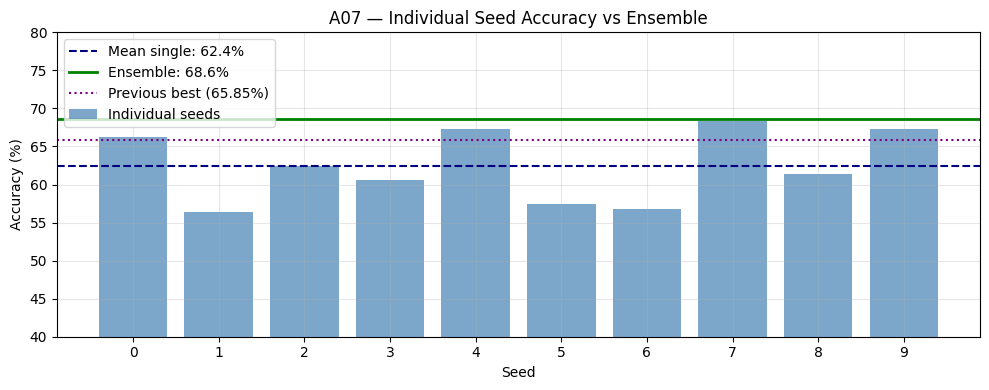

In [15]:
# Individual seed eval accuracies
seed_eval_accs = [accuracy_score(ye, np.argmax(p, axis=1)) for p in all_proba_eval]

print(f'Individual seed results:')
for i, (acc, kap) in enumerate(zip(seed_eval_accs, [cohen_kappa_score(ye, np.argmax(p,1)) for p in all_proba_eval])):
    print(f'  Seed {i:>2}: {acc*100:.2f}%  kappa={kap:.4f}')

print(f'\nSingle model: mean={np.mean(seed_eval_accs)*100:.2f}%  '
      f'std={np.std(seed_eval_accs)*100:.2f}%  '
      f'max={np.max(seed_eval_accs)*100:.2f}%')
print(f'Ensemble ({N_SEEDS} seeds): {final_acc*100:.2f}%  kappa={final_kappa:.4f}')
print(f'Gain from ensemble vs mean single: +{(final_acc - np.mean(seed_eval_accs))*100:.2f}%')

# Bar chart of individual seeds
plt.figure(figsize=(10, 4))
bars = plt.bar(range(N_SEEDS), [a*100 for a in seed_eval_accs],
               color='steelblue', alpha=0.7, label='Individual seeds')
plt.axhline(np.mean(seed_eval_accs)*100, color='navy',  ls='--', lw=1.5,
            label=f'Mean single: {np.mean(seed_eval_accs)*100:.1f}%')
plt.axhline(final_acc*100, color='green', ls='-', lw=2,
            label=f'Ensemble: {final_acc*100:.1f}%')
plt.axhline(65.85, color='purple', ls=':', lw=1.5, label='Previous best (65.85%)')
plt.xlabel('Seed')
plt.ylabel('Accuracy (%)')
plt.title('A07 — Individual Seed Accuracy vs Ensemble')
plt.xticks(range(N_SEEDS))
plt.ylim(40, 80)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()